# Informe interno del análisis e ingesta de datos de Dark Web

## Imports:
Estos son todos los imports necesarios para la ejecución completa de todas las celdas del trabajo, separados por secciones dependiendo de la función que realicen.

In [17]:
import pandas as pd
import seaborn as sns
from neo4j import GraphDatabase
from pymongo import MongoClient
import matplotlib.pyplot as plt
import os
from itables import show
import warnings
import itables.options as opt
import IPython
from IPython.display import display, HTML, IFrame, clear_output, FileLink, Javascript
import base64
import sys
import subprocess

### Conexiones:

Aquí vamos a configurar las diversas conexiones necesarias para el uso de las bases de datos utilizadas.

Primero de todo, se indican las variables globales necesarias en los códigos y conexiones.

In [18]:
NEO_URI = "bolt://localhost:7687"
NEO_USER = "neo4j"
NEO_PASS = "test1234"
MONGO_URI = "mongodb://localhost:27017"
MONGO_DB_NAME = "darkweb_tfg"

Se crean unas variables globales para todos los drivers de cada base de datos a utilizar.

In [19]:
neo_driver = None
mongo_client = None

Establece la conexión en las diversas bases de datos, tanto MongoDB como Neo4J

In [20]:
def get_mongo_connection():
    global mongo_client
    if mongo_client is None:
        try:
            mongo_client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
            mongo_client.admin.command('ismaster')
            print("Conexión a MongoDB exitosa.")
        except Exception as e:
            print(f"Error al conectar a MongoDB: {e}")
            mongo_client = None
    return mongo_client

In [21]:
def get_neo_driver():
    global neo_driver
    if neo_driver is None:
        try:
            neo_driver = GraphDatabase.driver(
                NEO_URI, 
                auth=(NEO_USER, NEO_PASS), 
                encrypted=False, 
                connection_timeout=5.0
            )
            neo_driver.verify_connectivity()
            print("Conexión a Neo4j exitosa.")
        except Exception as e:
            print(f"Error al conectar a Neo4j: {e}")
            neo_driver = None
    return neo_driver

Finalmente, se tienen las conexiones listas e iniciadas.

In [22]:
get_neo_driver()

Conexión a Neo4j exitosa.


In [23]:
get_mongo_connection()

Conexión a MongoDB exitosa.


MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True, serverselectiontimeoutms=5000)

### Cola de seeds (semillas) en MongoDB

Con este código se puede ver la distribución de la cola de los seeds que hay en MongoDB.  
Se puede ver en dos barras:
- **Pendientes:** que son las seeds que están esperando a ser procesadas.
- **Procesados:** que detro de los procesados tenemos 3 tipos distintos:
   - **Ingestados:** Ya están procesados y se tiene toda la información de cada uno de ellos.
   - **Datos insuficientes:** Se vio la página pero no cumple con el minimo datos en la página, entonces no se guarda ni coge la información (páginas únicamente de fotos, solo pagos...)
   - **Página inexistente:** Se vio la página pero la página no existe, es decir, tenemos la URL pero la página al intentar abrirla no existe porque ha desaparecido o la han borrado (es algo típico en la Dark Web)

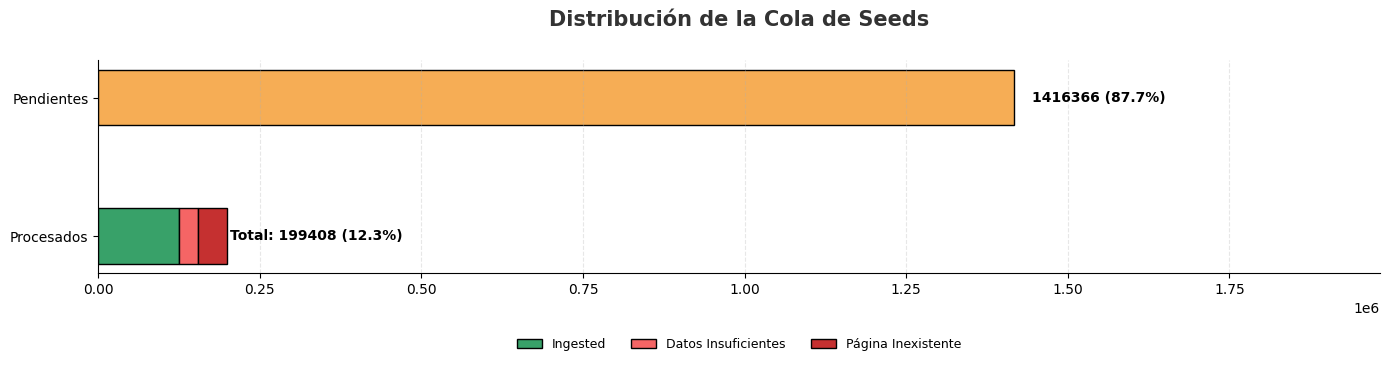


📊 TABLA RESUMEN DE ESTADOS:


Loading ITables v2.6.2 from the internet... (need help?)


In [24]:
# SILENCIAR WARNINGS
warnings.filterwarnings('ignore')
opt.style = "margin-left: 0; margin-right: auto; width: auto;"

# CONEXIÓN
if mongo_client:
    db = mongo_client[MONGO_DB_NAME]
    seeds_collection = db['seeds']
    
    # OBTENCIÓN DE DATOS DESDE MONGO
    total_seeds = seeds_collection.count_documents({})
    processed_seeds = seeds_collection.count_documents({'status': 'ingested'})
    unprocessed_seeds = seeds_collection.count_documents({'status': 'pending'})
    short_content = seeds_collection.count_documents({'status': 'discarded', 'discard_reason': 'too_short_content'})
    max_attempts_failed = seeds_collection.count_documents({'status': 'failed_perm'})

    # PREPARACIÓN DE LA GRÁFICA
    plt.figure(figsize=(14, 4), facecolor='none') 
    ax = plt.gca()
    ax.set_facecolor('none')
    
    # PENDIENTES
    plt.barh('Pendientes', unprocessed_seeds, color='#F6AD55', edgecolor='black', height=0.4)
    plt.text(unprocessed_seeds * 1.02, 0, f"{unprocessed_seeds} ({unprocessed_seeds/total_seeds*100:.1f}%)", 
             va='center', fontweight='bold', fontsize=10)
    
    # PROCESADOS
    plt.barh('Procesados', processed_seeds, color='#38A169', label='Ingested', height=0.4, edgecolor='black')
    plt.barh('Procesados', short_content, left=processed_seeds, color='#F56565', label='Datos Insuficientes', height=0.4, edgecolor='black')
    plt.barh('Procesados', max_attempts_failed, left=processed_seeds + short_content, color='#C53030', label='Página Inexistente', height=0.4, edgecolor='black')

    total_intento = processed_seeds + short_content + max_attempts_failed
    plt.text(total_intento * 1.02, 1, f"Total: {total_intento} ({total_intento/total_seeds*100:.1f}%)", 
             va='center', fontweight='bold', fontsize=10)

    plt.title('Distribución de la Cola de Seeds', fontsize=15, fontweight='bold', pad=25, color='#333')
    plt.xlim(0, max(unprocessed_seeds, total_intento) * 1.4)
    
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, shadow=False, frameon=False, fontsize=9)
    
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    sns.despine() 
    plt.tight_layout()
    plt.show()

    # TABLA
    print("\n📊 TABLA RESUMEN DE ESTADOS:")
    
    df_status = pd.DataFrame({
        'Estado / Motivo': ['Pendientes', 'Ingested', 'D. Insuficientes', 'P. Inexistente'],
        'Cantidad': [unprocessed_seeds, processed_seeds, short_content, max_attempts_failed],
        'Porcentaje (%)': [
            f"{(unprocessed_seeds/total_seeds)*100:.2f}%",
            f"{(processed_seeds/total_seeds)*100:.2f}%",
            f"{(short_content/total_seeds)*100:.2f}%",
            f"{(max_attempts_failed/total_seeds)*100:.2f}%"
        ]
    })
    
    display(HTML("""
        <style>
            .itables table { 
                margin-left: 0 !important; 
                margin-right: auto !important; 
                width: 700px !important; 
                max-width: 800px !important;
                font-size: 0.85em !important;
                border-collapse: collapse !important;
                table-layout: fixed !important;
            }
            .itables th, .itables td { 
                padding: 10px 15px !important; 
                white-space: nowrap !important;
                overflow: hidden;
                text-overflow: ellipsis;
            }
            .itables th { background-color: #f7fafc !important; border-bottom: 2px solid #edf2f7 !important; }
            .itables td { border-bottom: 1px solid #edf2f7 !important; }
        </style>
    """))
    
    show(df_status, 
         paging=False, 
         search=False, 
         info=False, 
         dom='t',
         autoWidth=False,
         columnDefs=[
             {"width": "300px", "targets": 0}, # Estado / Motivo
             {"width": "200px", "targets": 1}, # Cantidad
             {"width": "200px", "targets": 2}, # Porcentaje (%)
             {"className": "dt-left", "targets": "_all"}
         ])

    # GUARDADO
    ruta_graficas = 'Graficas'
    os.makedirs(ruta_graficas, exist_ok=True)
    path_archivo = os.path.join(ruta_graficas, 'estado_seeds.csv')
    df_status.to_csv(path_archivo, index=False)
    
    csv_data = df_status.to_csv(index=False)
    b64_csv = base64.b64encode(csv_data.encode()).decode()
    payload = f"data:text/csv;base64,{b64_csv}"
    
    display(HTML(f"""
    <div style="text-align: left; margin-top: 15px;">
        <span style="font-size: 10px; color: #718096; display: block; margin-bottom: 8px;">📁 Guardado en: {path_archivo}</span>
        <a href="{payload}" download="estado_seeds.csv" style="
            display: inline-block; background-color: #4299e1; color: white;
            padding: 6px 14px; text-decoration: none; border-radius: 6px;
            font-weight: 600; font-family: sans-serif; font-size: 12px;
        ">📥 Descargar CSV</a>
    </div>
    """))

Otra manera de mirar la cola de MongoDB y el estado de la bbdd

In [25]:
def ver_estado_seeds_mongo():
    print("🕵️‍♂️ Conectando a MongoDB para auditar la colección 'seeds'...")
    
    try:
        # 1. Conexión
        client = MongoClient(MONGO_URI)
        db = client[MONGO_DB_NAME]
        seeds_collection = db['seeds']
        
        # 2. Obtención de Conteos (Queries)
        # Total absoluto de semillas en la base de datos
        total_seeds = seeds_collection.count_documents({})
        
        # a) Procesadas Correctamente
        processed = seeds_collection.count_documents({'status': 'ingested'})
        
        # b) Pendientes de visitar
        pending = seeds_collection.count_documents({'status': 'pending'})
        
        # c) Descartadas por contenido corto (Basura/Vacías)
        short_content = seeds_collection.count_documents({
            'status': 'discarded', 
            'discard_reason': 'too_short_content'
        })
        
        # d) Fallidas permanentemente (404, Offline, Timeout)
        failed = seeds_collection.count_documents({'status': 'failed_perm'})
        
        # e) Otros descartes (idioma, duplicado, etc.)
        # Calculamos el resto para que los números cuadren
        otros_descartes = total_seeds - (processed + pending + short_content + failed)

        # 3. Creación del DataFrame para visualizar
        df_estado = pd.DataFrame({
            'Estado / Motivo': [
                '✅ Procesados (Ingested)', 
                '⏳ Pendientes', 
                '🗑️ Descartados (Contenido Corto)', 
                '❌ Fallidos (Offline/Error)',
                '⚠️ Otros Descartes',
                '--- TOTAL ---'
            ],
            'Cantidad': [
                processed, 
                pending, 
                short_content, 
                failed,
                otros_descartes,
                total_seeds
            ]
        })

        # Añadimos columna de Porcentaje
        df_estado['Porcentaje'] = (df_estado['Cantidad'] / total_seeds * 100).round(2).astype(str) + '%'
        
        # Ajustamos el porcentaje del total para que quede limpio
        df_estado.iloc[-1, df_estado.columns.get_loc('Porcentaje')] = '100%'

        # 4. Visualización Bonita en Jupyter
        print(f"\n📊 ESTADO ACTUAL DEL CRAWLER (Base de datos: {MONGO_DB_NAME})")
        
        # Estilo CSS para la tabla
        estilo = [
            dict(selector="th", props=[("font-size", "14px"), ("text-align", "left"), ("background-color", "#f0f2f6")]),
            dict(selector="td", props=[("font-size", "14px"), ("padding", "10px")])
        ]
        
        # Mostramos la tabla coloreada
        display(df_estado.style.set_table_styles(estilo).background_gradient(cmap='Blues', subset=['Cantidad']))

        return df_estado

    except Exception as e:
        print(f"❌ Error conectando a Mongo: {e}")
        return None

# --- EJECUTAR ---
df_resultado = ver_estado_seeds_mongo()

🕵️‍♂️ Conectando a MongoDB para auditar la colección 'seeds'...

📊 ESTADO ACTUAL DEL CRAWLER (Base de datos: darkweb_tfg)


,Estado / Motivo,Cantidad,Porcentaje
0,✅ Procesados (Ingested),125257,7.75%
1,⏳ Pendientes,1416366,87.66%
2,🗑️ Descartados (Contenido Corto),28333,1.75%
3,❌ Fallidos (Offline/Error),45818,2.84%
4,⚠️ Otros Descartes,4,0.0%
5,--- TOTAL ---,1615778,100%


### Colores utilizados en el proyecto

Paleta de colores a utilizar en el proyecto para poder tener un entorno con todos los colores separados por las diversas tematicas.

In [26]:
colores_tfg = {
    'drugs':       '#48BB78', 'carding':     '#ECC94B',
    'hacking':     '#0BC5EA', 'ransomware':  '#F56565',
    'weapon':      '#DD6B20', 'marketplace': '#4299E1',
    'phone':       '#A0AEC0', 'fraud':       '#9F7AEA'
}

### Análisis ingesta Neo4J

Con este código vamos a ver la cantidad de nodos y de relaciones que tenemos dentro del Neo4J

In [27]:
if neo_driver:
    session = neo_driver.session()
    
    # Consulta para contar todos los nodos y relaciones
    query_counts = """
    CALL db.labels() YIELD label AS node_type
    RETURN node_type, size(nodes(shortestPath((n)-[*]->(n)))) AS count
    UNION ALL
    CALL db.relationshipTypes() YIELD relationshipType AS node_type
    RETURN relationshipType, count(r) AS count
    """ 
    node_counts = session.run("""
    MATCH (n)
    RETURN labels(n) AS node_labels, count(n) AS count
    """)
    rel_counts = session.run("""
    MATCH ()-[r]->()
    RETURN type(r) AS rel_type, count(r) AS count
    """)
    
    data_nodes = {}
    for record in node_counts:
        label = ":".join(record["node_labels"]) 
        data_nodes[label] = record["count"]

    data_rels = {record["rel_type"]: record["count"] for record in rel_counts}

    print("--- Conteo de Nodos ---")
    for k, v in data_nodes.items():
        print(f"Nodos '{k}': {v}")
        
    print("\n--- Conteo de Relaciones ---")
    for k, v in data_rels.items():
        print(f"Relaciones '{k}': {v}")

--- Conteo de Nodos ---
Nodos 'Page': 1689
Nodos 'Term': 8
Nodos 'Synonym': 33
Nodos 'Page:Seed': 1613314

--- Conteo de Relaciones ---
Relaciones 'IS_SYNONYM_OF': 41
Relaciones 'MENTIONS': 377942
Relaciones 'LINKS_TO': 1835622


Con esto se ve el total de nodos que hay en Neo4J, para ver también cuantos de ellos tienen información completa y cuantos no.

In [28]:
def imprimir_resumen_calidad_total():
    try:
        # Consulta NEO
        query = """
        MATCH (p:Page)
        WITH p,
             (p.title IS NOT NULL AND size(trim(toString(p.title))) > 0 AND
              p.text IS NOT NULL AND size(trim(toString(p.text))) > 0) as es_completo
        RETURN 
            count(p) as total,
            sum(CASE WHEN es_completo THEN 1 ELSE 0 END) as completos,
            sum(CASE WHEN NOT es_completo THEN 1 ELSE 0 END) as incompletos
        """
        
        with neo_driver.session() as session:
            res = session.run(query).single()
        
        if not res or res['total'] == 0:
            print("No hay datos en los nodos :Page para analizar.")
            return

        total = res['total']
        completos = res['completos']
        incompletos = res['incompletos']
        pct_ok = (completos / total) * 100
        pct_ko = (incompletos / total) * 100

        print("\n" + "="*40)
        print("📊 AUDITORÍA DE INTEGRIDAD DEL DATASET")
        print("="*40)
        print(f"Total de nodos analizados: {total:,}")
        print(f"---")
        print(f"✅ Información Completa:   {completos:,} ({pct_ok:.1f}%)")
        print(f"❌ Información Incompleta: {incompletos:,} ({pct_ko:.1f}%)")
        print("="*40)

    except Exception as e:
        print(f"❌ Error al obtener los datos: {e}")

imprimir_resumen_calidad_total()


📊 AUDITORÍA DE INTEGRIDAD DEL DATASET
Total de nodos analizados: 1,615,003
---
✅ Información Completa:   125,239 (7.8%)
❌ Información Incompleta: 1,489,764 (92.2%)


En la tabla siguiente se pueden ver los datos que contiene Neo4J de cada uno de los nodos y páginas, para poder realizar un análisis más completo.

In [29]:
def extractor_exhaustivo_neo4j(driver):
    print("🕵️ Iniciando inspección profunda de la base de datos...")
    
    esquema_final = []
    
    with driver.session() as session:
        # 1. Obtener todas las etiquetas de nodos (Labels)
        labels_query = "CALL db.labels()"
        labels = [row[0] for row in session.run(labels_query)]
        
        for label in labels:
            # 2. Para cada etiqueta, buscar TODAS las propiedades únicas que existen
            # Usamos apoc si está disponible, o una consulta exhaustiva
            prop_query = f"""
            MATCH (n:{label})
            UNWIND keys(n) AS key
            RETURN DISTINCT key AS propiedad
            """
            props = [row['propiedad'] for row in session.run(prop_query)]
            
            # 3. Contar cuántos nodos hay de este tipo (útil para la memoria del TFG)
            count_query = f"MATCH (n:{label}) RETURN count(n) AS total"
            total = session.run(count_query).single()['total']
            
            esquema_final.append({
                "Elemento": "NODO",
                "Etiqueta / Tipo": label,
                "Nº Total": total,
                "Propiedades Detectadas": ", ".join(sorted(props))
            })

        # 4. Obtener todas las relaciones y sus propiedades (si tienen)
        rel_query = """
        MATCH (a)-[r]->(b)
        WITH type(r) AS tipo, labels(a)[0] AS origen, labels(b)[0] AS destino, keys(r) AS prop_rels
        UNWIND (CASE WHEN prop_rels = [] THEN [null] ELSE prop_rels END) AS p
        RETURN DISTINCT tipo, origen, destino, collect(DISTINCT p) AS propiedades
        """
        rels = session.run(rel_query).data()
        for r in rels:
            props_list = [p for p in r['propiedades'] if p is not None]
            esquema_final.append({
                "Elemento": "RELACIÓN",
                "Etiqueta / Tipo": f"{r['tipo']} ({r['origen']} → {r['destino']})",
                "Nº Total": "-", 
                "Propiedades Detectadas": ", ".join(props_list) if props_list else "Sin propiedades"
            })

    # Crear DataFrame y mostrar con estilo
    df = pd.DataFrame(esquema_final)
    
    print("\n📋 DICCIONARIO DE DATOS COMPLETO (NEO4J):")
    display(HTML(f"""
        <style>
            .neo-table {{ border-collapse: collapse; width: 100%; font-family: sans-serif; font-size: 13px; }}
            .neo-table th {{ background-color: #4A5568; color: white; padding: 10px; text-align: left; }}
            .neo-table td {{ border: 1px solid #E2E8F0; padding: 8px; vertical-align: top; }}
            .neo-table tr:nth-child(even) {{ background-color: #F7FAFC; }}
            .tag-node {{ color: #2B6CB0; fontweight: bold; }}
            .tag-rel {{ color: #C53030; fontweight: bold; }}
        </style>
        {df.to_html(index=False, classes='neo-table')}
    """))
    
    return df

# Ejecutar
if 'neo_driver' in locals() and neo_driver:
    diccionario_tfg = extractor_exhaustivo_neo4j(neo_driver)

🕵️ Iniciando inspección profunda de la base de datos...

📋 DICCIONARIO DE DATOS COMPLETO (NEO4J):


Elemento,Etiqueta / Tipo,Nº Total,Propiedades Detectadas
NODO,Page,1615003,"cluster, cluster_name, comunidad_louvain, first_seen, first_seen_as_link, has_html_content, host, text, title, updated_at, url"
NODO,Term,8,name
NODO,Synonym,33,name
NODO,Seed,1613314,"cluster, cluster_name, comunidad_louvain, first_seen_as_link, text, title, updated_at, url"
RELACIÓN,IS_SYNONYM_OF (Synonym → Term),-,Sin propiedades
RELACIÓN,MENTIONS (Page → Synonym),-,"count, root, source, first_seen"
RELACIÓN,LINKS_TO (Page → Page),-,"count, depth, first_detected, last_detected, last_anchor"


### Análisis de duplicados

Con el siguiente código, se puede ver si en el dataset se contienen duplicados o no, para poder asegurar que la ingesta es limpia de duplicados.

In [30]:
def diagnostico_neo(neo_driver):
    print("🧮 Contando páginas en la base de datos...")
    
    with neo_driver.session() as session:
        # 1. Cuenta TOTAL de nodos (bolas) de tipo Page
        result_total = session.run("MATCH (p:Page) RETURN count(p) as total")
        total_nodos = result_total.single()['total']
        
        # 2. Cuenta URLs ÚNICAS (direcciones distintas)
        result_unicas = session.run("MATCH (p:Page) RETURN count(DISTINCT p.url) as unicas")
        urls_unicas = result_unicas.single()['unicas']
        
        print("\n" + "="*40)
        print(f"📊 RESULTADO DE LA AUDITORÍA:")
        print("="*40)
        print(f"🔵 Total de Nodos 'Page':   {total_nodos:,}")
        print(f"✨ URLs Únicas reales:     {urls_unicas:,}")
        
        diferencia = total_nodos - urls_unicas
        
        if diferencia > 0:
            print(f"⚠️ ¡ALERTA! Tienes {diferencia:,} páginas DUPLICADAS.")
            print("   (Esto explica por qué te salían 125.000 en el gráfico)")
        else:
            print("✅ Tu base de datos está limpia. No hay duplicados.")
            
    return total_nodos, urls_unicas

# EJECUCIÓN
total, unicas = diagnostico_neo(neo_driver)

🧮 Contando páginas en la base de datos...

📊 RESULTADO DE LA AUDITORÍA:
🔵 Total de Nodos 'Page':   1,615,003
✨ URLs Únicas reales:     1,615,003
✅ Tu base de datos está limpia. No hay duplicados.


### Análisis porcentual sobre el total de datos

Sobre el total de la muestra de datos que se encuentra en Neo4J se puede ver el porcentaje que representa cada tematica sobre el total de datos ingestados.

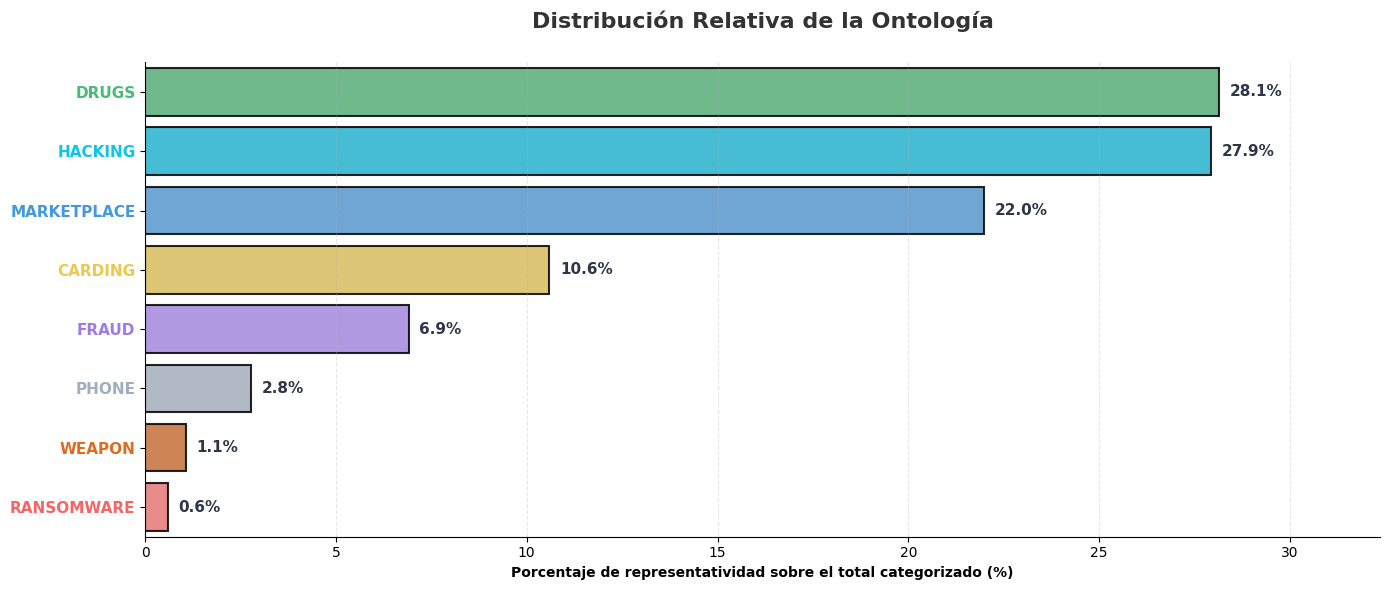


📊 DETALLE DE DISTRIBUCIÓN RELATIVA:


Loading ITables v2.6.2 from the internet... (need help?)


In [31]:
# SILENCIAR

opt.warn_on_undocumented_option = False
pd.options.mode.chained_assignment = None 

# CONEXION
if neo_driver:
    session = neo_driver.session()

    # CONSULTA: Obtenemos el conteo de páginas por cada término
    query_alcance = """
    MATCH (root:Term)
    OPTIONAL MATCH (synonym:Synonym)-[:IS_SYNONYM_OF]->(root)
    WITH root, collect(toLower(synonym.name)) + toLower(root.name) AS all_keywords
    OPTIONAL MATCH (p:Page)
    WHERE ANY(word IN all_keywords WHERE toLower(p.text) CONTAINS toLower(word))
    RETURN root.name AS term_name, COUNT(DISTINCT p) AS page_count
    """
    
    try:
        results = session.run(query_alcance).data()
        session.close()
        
        df_alcance = pd.DataFrame(results)

        # Cálculo de hegemonía relativa
        total_paginas_categorias = df_alcance['page_count'].sum()
        df_alcance['Alcance (%)'] = (df_alcance['page_count'] / total_paginas_categorias) * 100
        
        # Ordenamos y Top 10
        df_alcance = df_alcance.sort_values(by='Alcance (%)', ascending=False).head(10)
        
        # --- GRÁFICA ---
        plt.figure(figsize=(14, 6), facecolor='none')
        ax = plt.gca()
        ax.set_facecolor('none')
        
        # Colores dinámicos (asegúrate de tener definido colores_tfg)
        lista_colores = [colores_tfg.get(x.lower(), '#2D3748') for x in df_alcance['term_name']]

        plot = sns.barplot(
            data=df_alcance, 
            x='Alcance (%)', 
            y='term_name', 
            hue='term_name',
            palette=lista_colores, 
            legend=False,
            edgecolor='black', 
            linewidth=1.5,
            alpha=0.85
        )

        max_val = df_alcance['Alcance (%)'].max()
        for p in plot.patches:
            val = p.get_width()
            if val > 0:
                plt.text(val + (max_val * 0.01), p.get_y() + p.get_height() / 2, 
                         f'{val:.1f}%', va='center', fontweight='bold', fontsize=11, color='#2d3748')
        
        ax.set_yticks(range(len(df_alcance)))
        ax.set_yticklabels([str(n).upper() for n in df_alcance['term_name']], fontweight='bold', fontsize=11)
        for i, tick in enumerate(ax.get_yticklabels()):
            tick.set_color(lista_colores[i])
            
        plt.title('Distribución Relativa de la Ontología', 
                  fontsize=16, fontweight='bold', pad=25, color='#333')
        plt.xlabel('Porcentaje de representatividad sobre el total categorizado (%)', fontsize=10, fontweight='bold')
        plt.ylabel('', fontsize=0)
        plt.grid(axis='x', linestyle='--', alpha=0.3)
        plt.xlim(0, max_val * 1.15)
        sns.despine()
        plt.tight_layout()
        
        # Guardado de imagen
        os.makedirs('Graficas', exist_ok=True)
        path_img = 'Graficas/barras_distribucion.png'
        plt.savefig(path_img, dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()

        # --- TABLA (FORMATO UNIFICADO) ---
        df_tabla = df_alcance.copy().reset_index(drop=True)
        df_tabla['term_name'] = df_tabla['term_name'].str.upper()
        df_tabla['Alcance (%)'] = df_tabla['Alcance (%)'].round(2)
        df_tabla.columns = ['Categoría', 'Páginas Únicas', 'Alcance (%)']
        
        print("\n📊 DETALLE DE DISTRIBUCIÓN RELATIVA:")
        
        display(HTML("""
            <style>
                .jp-RenderedHTMLCommon table, .rendered_html table { margin-left: 0 !important; margin-right: auto !important; }
                .itables { text-align: left !important; margin-left: 0 !important; }
                .itables table { 
                    margin-left: 0 !important; margin-right: auto !important; 
                    width: 700px !important; max-width: 800px !important;
                    font-size: 0.85em !important; border-collapse: collapse !important;
                    table-layout: fixed !important; 
                }
                .itables th, .itables td { 
                    padding: 10px 15px !important; text-align: left !important;
                    white-space: nowrap !important; overflow: hidden; text-overflow: ellipsis;
                }
                .itables th { background-color: #f7fafc !important; border-bottom: 2px solid #edf2f7 !important; }
                .itables td { border-bottom: 1px solid #edf2f7 !important; }
            </style>
            """))

        show(df_tabla, 
             paging=False, search=False, info=False, dom='t', autoWidth=False,
             columnDefs=[
                 {"width": "300px", "targets": 0, "className": "dt-left"},
                 {"width": "200px", "targets": 1, "className": "dt-left"},
                 {"width": "200px", "targets": 2, "className": "dt-left"},
                 {"className": "dt-left", "targets": "_all"}
             ])

        # --- SECCIÓN DE GUARDADO Y BOTÓN CSV ---
        path_csv = 'Graficas/clasificacion_tematica.csv'
        df_tabla.to_csv(path_csv, index=False)
        
        csv_data = df_tabla.to_csv(index=False)
        b64_csv = base64.b64encode(csv_data.encode()).decode()
        payload = f"data:text/csv;base64,{b64_csv}"
        
        display(HTML(f"""
        <div style="text-align: left; margin-top: 15px;">
            <span style="font-size: 10px; color: #718096; display: block; margin-bottom: 8px;">📁 Guardado en: {path_csv}</span>
            <a href="{payload}" download="hegemonia_tematica.csv" style="
                display: inline-block; background-color: #4299e1; color: white;
                padding: 6px 14px; text-decoration: none; border-radius: 6px;
                font-weight: 600; font-family: sans-serif; font-size: 12px;
            ">📥 Descargar CSV</a>
        </div>
        """))

    except Exception as e:
        print(f"❌ Error: {e}")

### Profundidad de la ingesta

En esta representación se puede ver por que profundidad va la ingesta en estos momentos.

In [32]:
def get_crawler_depth_report(neo_driver):
    """
    Calcula la profundidad X basándose en la estructura de saltos 
    que genera tu TorController de forma eficiente.
    """
    print("🌐 Analizando saltos del crawler en Neo4j...")

    query = """
    MATCH (p:Page)
    WITH p ORDER BY elementId(p) DESC LIMIT 1
    
    MATCH path = shortestPath((root:Page)-[*0..20]->(p))
    WHERE NOT ()-->(root) AND root:Page
    
    RETURN 
        p.url AS url,
        p.title AS titulo,
        length(path) AS profundidad_x,
        [n in nodes(path) | n.url] AS ruta_urls
    LIMIT 1
    """

    try:
        with neo_driver.session() as session:
            result = session.run(query).data()

        if not result:
            query_alt = query.replace(":Page", ":Term")
            with neo_driver.session() as session:
                result = session.run(query_alt).data()

        if not result:
            print("❌ No se encontró una jerarquía conectada. Es posible que los nodos estén aislados.")
            return

        res = result[0]
        depth = res['profundidad_x']
        
        # Generamos el HTML
        html_content = f"""
            <div style="font-family: sans-serif; border: 1px solid #cbd5e0; border-radius: 12px; overflow: hidden; width: 100%; max-width: 650px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1);">
                <div style="background: #2d3748; color: white; padding: 12px 20px; font-weight: bold; display: flex; justify-content: space-between; align-items: center;">
                    <span style="letter-spacing: 1px;">MONITOR DE INGESTA TOR</span>
                    <span style="background: #48bb78; color: white; padding: 2px 8px; border-radius: 20px; font-size: 0.7em;">ACTIVO</span>
                </div>
                <div style="padding: 25px; background: #f7fafc;">
                    <div style="display: flex; align-items: center; gap: 15px; margin-bottom: 20px;">
                        <div style="background: #3182ce; color: white; padding: 15px; border-radius: 10px; text-align: center; min-width: 120px;">
                            <div style="font-size: 0.8em; opacity: 0.9;">PROFUNDIDAD</div>
                            <div style="font-size: 2em; font-weight: 800;">X = {depth}</div>
                        </div>
                        <div>
                            <p style="margin: 0; color: #2d3748; font-weight: bold; font-size: 1.1em;">{res['titulo'] or 'Sin título detectado'}</p>
                            <p style="margin: 5px 0 0 0; color: #718096; font-family: monospace; font-size: 0.85em; word-break: break-all;">{res['url']}</p>
                        </div>
                    </div>
                    
                    <div style="border-top: 1px solid #e2e8f0; padding-top: 15px;">
                        <p style="margin: 0 0 8px 0; font-size: 0.75em; color: #4a5568; font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Traza de propagación (últimos saltos):</p>
                        <div style="background: white; padding: 12px; border-radius: 8px; border: 1px dashed #cbd5e0; font-family: monospace; font-size: 0.8em; color: #2d3748;">
                            {" <br> <span style='color:#3182ce'>➔</span> ".join(res['ruta_urls'][-3:])}
                            {f"<br><i style='color:#a0aec0'>... (+{len(res['ruta_urls'])-3} niveles anteriores)</i>" if len(res['ruta_urls']) > 3 else ""}
                        </div>
                    </div>
                </div>
            </div>
        """
        display(HTML(html_content))

    except Exception as e:
        print(f"❌ Error al ejecutar el reporte: {e}")

# Ejecución
get_crawler_depth_report(neo_driver)

🌐 Analizando saltos del crawler en Neo4j...


### Impresión del PDF final

Se imprime el PDF con todas las explicaciones (markdown) y las graficas con sus respectivas tablas.

In [33]:
# CONFIGURACIÓN
nombre_notebook = "Interno.ipynb" 
nombre_pdf_final = "TFG_Sandra_Final_Interno.pdf"

print("🎨 Generando el PDF filtrado...")

comando = [
    sys.executable, "-m", "nbconvert", 
    "--to", "webpdf",
    "--no-input", 
    "--TagRemovePreprocessor.remove_cell_tags={'ocultar'}", 
    "--WebPDFExporter.metadata={'orientation': 'landscape'}", 
    "--WebPDFExporter.scale=0.6", 
    "--WebPDFExporter.margin=5mm",
    "--allow-chromium-download",
    nombre_notebook,
    "--output", nombre_pdf_final
]

try:
    resultado = subprocess.run(comando, capture_output=True, text=True, check=True)
    print(f"✅ ¡CONSEGUIDO! PDF generado sin los elementos ocultos.")
    print(f"📂 Ubicación: {os.getcwd()}/{nombre_pdf_final}")
except subprocess.CalledProcessError as e:
    print("❌ ERROR CRÍTICO:")
    print(e.stderr)

🎨 Generando el PDF filtrado...
✅ ¡CONSEGUIDO! PDF generado sin los elementos ocultos.
📂 Ubicación: C:\Users\sandr\TFG\Interno/TFG_Sandra_Final_Interno.pdf
